In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  

In [5]:
X_test_ml_glcm = np.load("C:/DatePalmDisease/ml/X_test_glcm.npy")
X_test_ml_glcm_hsv = np.load("C:/DatePalmDisease/ml/X_test_glcm_hsv.npy")
y_test_ml = np.load("C:/DatePalmDisease/ml/y_test_glcm.npy")  


X_test_cnn = np.load("C:/DatePalmDisease/X_CNN.npy")
y_test_cnn = np.load("C:/DatePalmDisease/y_CNN.npy")  

In [11]:
import pandas as pd
from tabulate import tabulate

# File paths
ml_metrics_path = r"C:\DatePalmDisease\ML_Comparison.csv"
cnn_metrics_path = r"C:\DatePalmDisease\CNN_Model_Metrics.csv"

# Read CSVs and ensure the first column is set as the index (model names)
ml_df = pd.read_csv(ml_metrics_path, index_col=0)
cnn_df = pd.read_csv(cnn_metrics_path, index_col=0)

# Set index name properly
ml_df.index.name = "Model"
cnn_df.index.name = "Model"

# Print ML Model Metrics Table
print("\n ML Model Metrics:\n")
print(tabulate(ml_df, headers="keys", tablefmt="fancy_grid", showindex=True))

# Print CNN Model Metrics Table
print("\n CNN Model Metrics:\n")
print(tabulate(cnn_df, headers="keys", tablefmt="fancy_grid", showindex=True))



 ML Model Metrics:

╒═══════════════╤════════════╤═════════════╤══════════╤════════════╕
│ Model         │   Accuracy │   Precision │   Recall │   F1-Score │
╞═══════════════╪════════════╪═════════════╪══════════╪════════════╡
│ SVM_GLCM      │   0.930265 │    0.936179 │ 0.930265 │   0.930796 │
├───────────────┼────────────┼─────────────┼──────────┼────────────┤
│ SVM_GLCM_HSV  │   0.987448 │    0.987477 │ 0.987448 │   0.987459 │
├───────────────┼────────────┼─────────────┼──────────┼────────────┤
│ KNN_GLCM      │   0.909344 │    0.910188 │ 0.909344 │   0.909332 │
├───────────────┼────────────┼─────────────┼──────────┼────────────┤
│ KNN_GLCM_HSV  │   0.973501 │    0.973568 │ 0.973501 │   0.973497 │
├───────────────┼────────────┼─────────────┼──────────┼────────────┤
│ RF_GLCM       │   0.887029 │    0.895103 │ 0.887029 │   0.887501 │
├───────────────┼────────────┼─────────────┼──────────┼────────────┤
│ RF_GLCM_HSV   │   0.945607 │    0.948865 │ 0.945607 │   0.945978 │
├────────────

In [55]:
import pandas as pd
from tabulate import tabulate

# Add model names as a column (reset index)
ml_metrics_df = ml_metrics_df.copy()
ml_metrics_df['Model'] = ml_metrics_df.index
ml_metrics_df.reset_index(drop=True, inplace=True)

cnn_metrics_df = cnn_metrics_df.copy()
cnn_metrics_df['Model'] = cnn_metrics_df.index
cnn_metrics_df.reset_index(drop=True, inplace=True)

# Combine ML and CNN metrics into one DataFrame
combined_df = pd.concat([ml_metrics_df, cnn_metrics_df], ignore_index=True)

# Reorder columns (Model first)
cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
combined_df = combined_df[cols]

# Sort by Accuracy (descending)
combined_df_sorted = combined_df.sort_values(by='Accuracy', ascending=False)

# Save to CSV
csv_path = r"C:\DatePalmDisease\All_Model_Metrics_Comparison.csv"
combined_df_sorted.to_csv(csv_path, index=False)

# Print tabulated output
print("\nAll Model Metrics Comparison:\n")
print(tabulate(combined_df_sorted, headers='keys', tablefmt="fancy_grid"))

# Show where it’s saved
print(f"\nCombined metrics saved to: {csv_path}")



All Model Metrics Comparison:

╒════╤═══════════════╤════════════╤═════════════╤══════════╤════════════╕
│    │ Model         │   Accuracy │   Precision │   Recall │   F1-Score │
╞════╪═══════════════╪════════════╪═════════════╪══════════╪════════════╡
│  9 │ MobileNetV2   │   0.9944   │    0.9945   │ 0.9943   │   0.9944   │
├────┼───────────────┼────────────┼─────────────┼──────────┼────────────┤
│  1 │ SVM_GLCM_HSV  │   0.987448 │    0.987477 │ 0.987448 │   0.987459 │
├────┼───────────────┼────────────┼─────────────┼──────────┼────────────┤
│ 11 │ DenseNet121   │   0.9861   │    0.9864   │ 0.9862   │   0.9862   │
├────┼───────────────┼────────────┼─────────────┼──────────┼────────────┤
│  8 │ ResNet50      │   0.9833   │    0.9835   │ 0.9834   │   0.9834   │
├────┼───────────────┼────────────┼─────────────┼──────────┼────────────┤
│  3 │ KNN_GLCM_HSV  │   0.973501 │    0.973568 │ 0.973501 │   0.973497 │
├────┼───────────────┼────────────┼─────────────┼──────────┼────────────┤
│  7 │

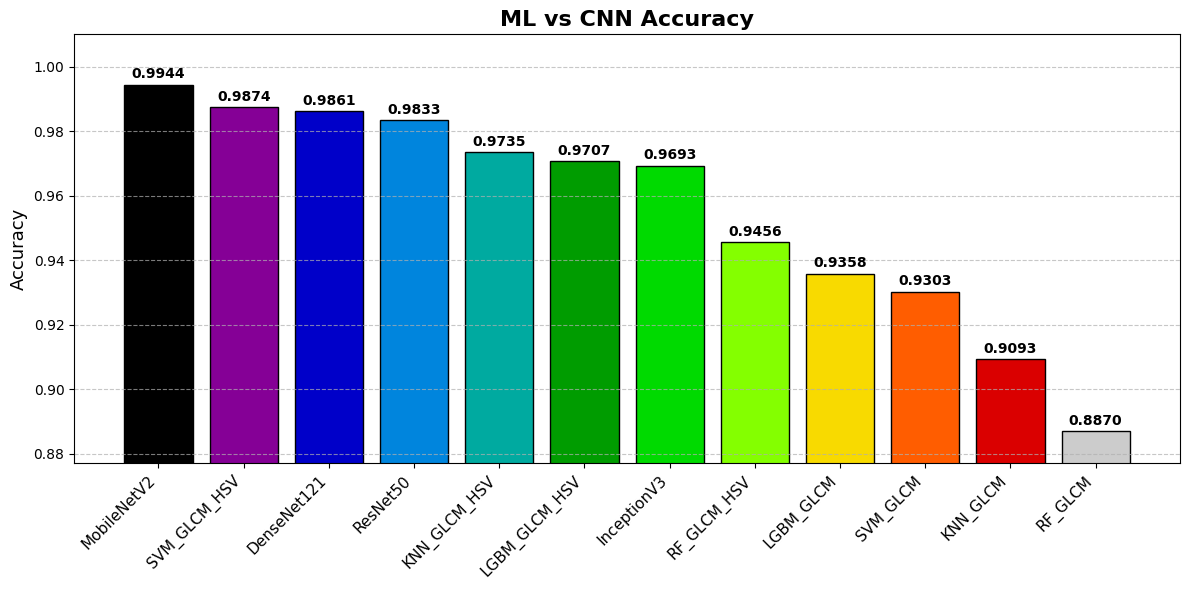

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

df = pd.read_csv(r"C:\DatePalmDisease\All_Model_Metrics_Comparison.csv")

cnn_keywords = ['ResNet', 'DenseNet', 'Inception', 'MobileNet']
df['Type'] = df['Model'].apply(lambda name: 'CNN' if any(kw in name for kw in cnn_keywords) else 'ML')

df_sorted = df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

color_map = plt.colormaps['nipy_spectral']
colors = [color_map(i) for i in np.linspace(0, 1, len(df_sorted))]
model_colors = {model: colors[i] for i, model in enumerate(df_sorted['Model'])}
bar_colors = [model_colors[model] for model in df_sorted['Model']]

plt.figure(figsize=(12, 6))
bars = plt.bar(df_sorted['Model'], df_sorted['Accuracy'], color=bar_colors, edgecolor='black')
for bar, acc in zip(bars, df_sorted['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.002, f"{acc:.4f}", ha='center', fontsize=10, fontweight='bold')
plt.title("ML vs CNN Accuracy", fontsize=16, fontweight='bold')
plt.ylabel("Accuracy", fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.ylim(df_sorted['Accuracy'].min() - 0.01, 1.01)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


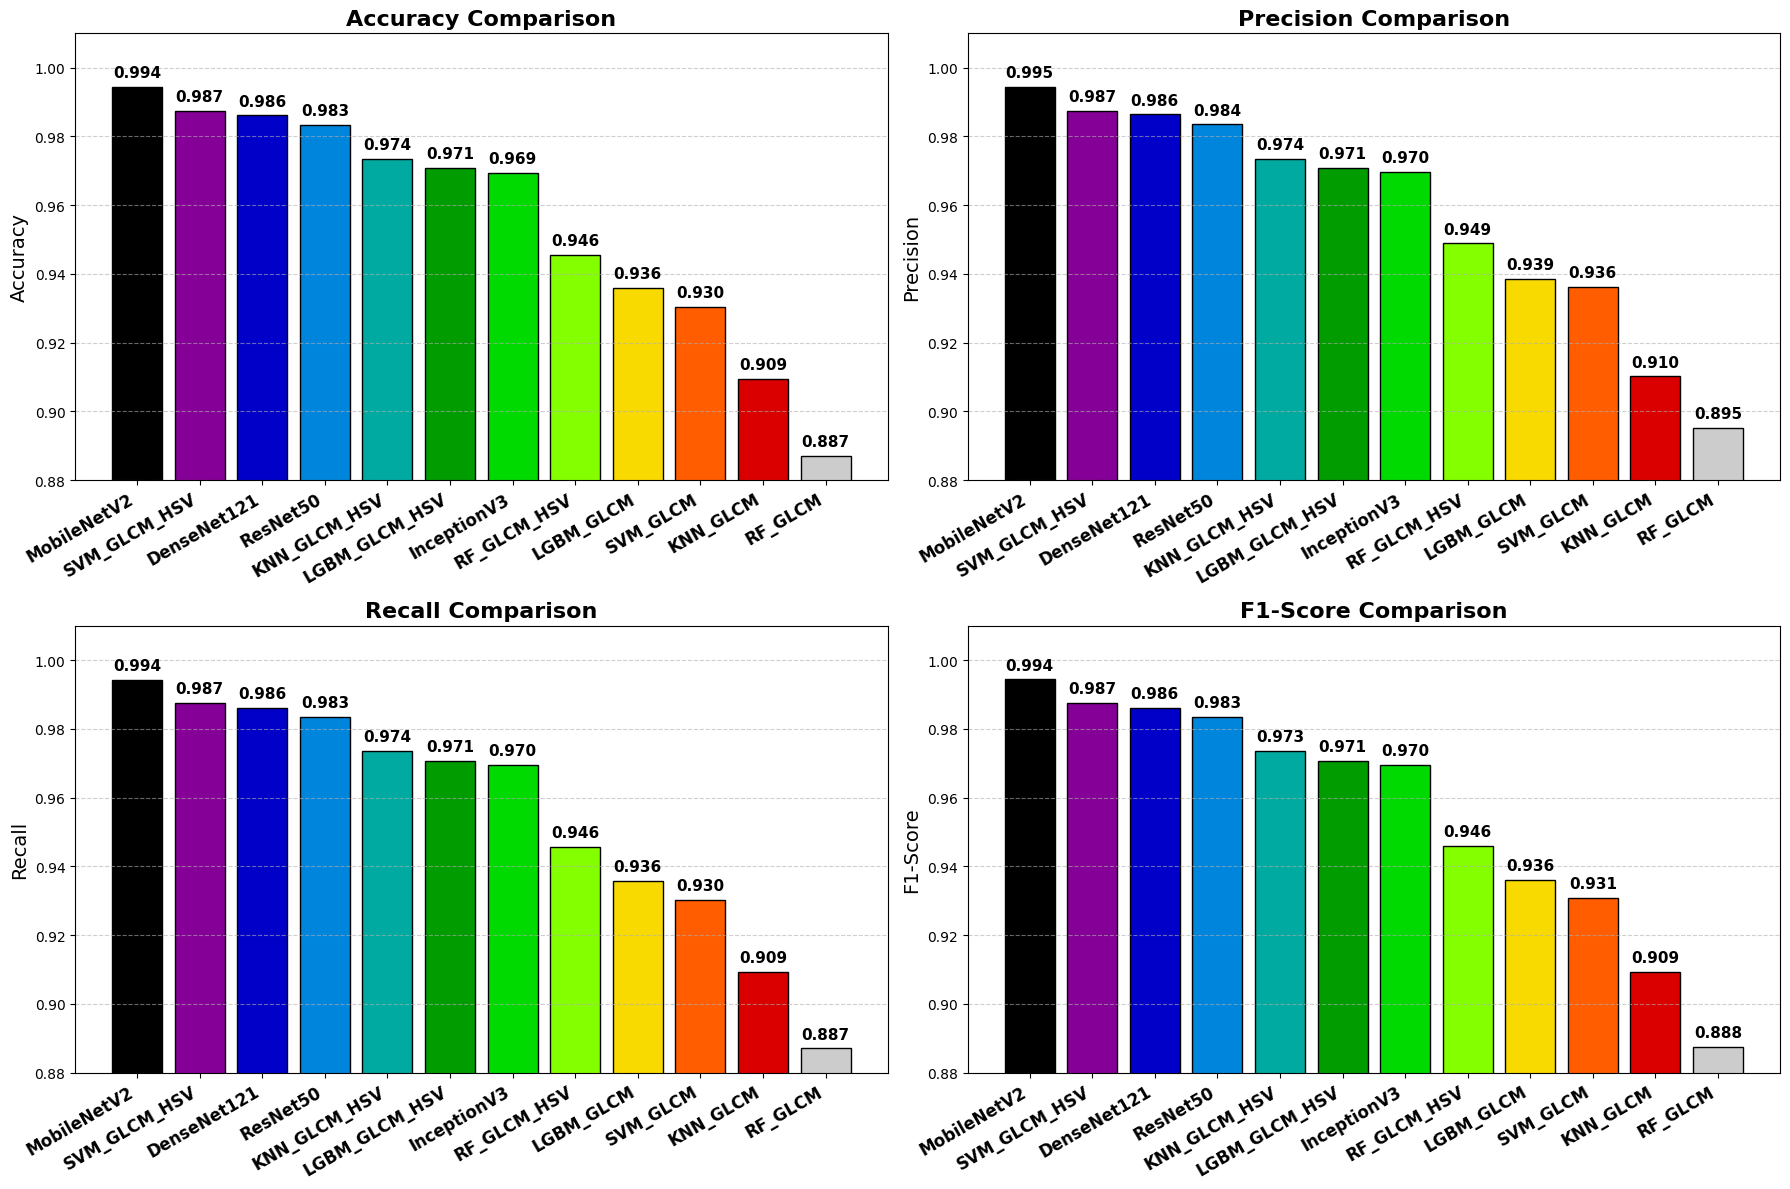

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

metrics_path = r"C:\DatePalmDisease\All_Model_Metrics_Comparison.csv"
combined_df = pd.read_csv(metrics_path, index_col=0)
models = combined_df.index.tolist()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

color_map = plt.colormaps['nipy_spectral']
colors = [color_map(i) for i in np.linspace(0, 1, len(models))]
model_colors = {model: colors[i] for i, model in enumerate(models)}

# --- Plot 2x2 grid ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(
        combined_df.index,
        combined_df[metric],
        color=[model_colors[model] for model in combined_df.index],
        edgecolor='black'
    )

    ax.set_title(f'{metric} Comparison', fontsize=16, fontweight='bold')
    ax.set_ylabel(metric, fontsize=14)
    ax.set_ylim(0.88, 1.01)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=12, fontweight='bold')

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.002,
            f'{height:.3f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold'
        )

# --- Layout ---
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


In [81]:
import pandas as pd
from tabulate import tabulate

# --- Load combined model metrics ---
file_path = r"C:\DatePalmDisease\All_Model_Metrics_Comparison.csv"
df = pd.read_csv(file_path, index_col=0)

# --- Round metrics ---
df = df.round(4)

# --- Select best model based on F1-Score ---
best_model = df['F1-Score'].idxmax()
best_metrics = df.loc[best_model]

# --- Format results using tabulate ---
table = [
    ["Model Name", best_model],
    ["Accuracy", best_metrics['Accuracy']],
    ["Precision", best_metrics['Precision']],
    ["Recall", best_metrics['Recall']],
    ["F1-Score", best_metrics['F1-Score']]
]

# --- Display ---
print("\n=== Best Model Selected for Deployment ===\n")
print(tabulate(table, headers=["Metric", "Value"], tablefmt="fancy_grid"))



=== Best Model Selected for Deployment ===

╒════════════╤═════════════╕
│ Metric     │ Value       │
╞════════════╪═════════════╡
│ Model Name │ MobileNetV2 │
├────────────┼─────────────┤
│ Accuracy   │ 0.9944      │
├────────────┼─────────────┤
│ Precision  │ 0.9945      │
├────────────┼─────────────┤
│ Recall     │ 0.9943      │
├────────────┼─────────────┤
│ F1-Score   │ 0.9944      │
╘════════════╧═════════════╛
